# VisDrone Dataset Analysis

This notebook summarizes class distribution, image dimensions, box sizes, and dataset mean/std.

In [1]:
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

sns.set_theme(style='whitegrid')
%matplotlib inline

CONFIG_PATH = Path('..') / 'config' / 'config.json'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    config = json.load(f)

train_cfg = config['data']['train']
val_cfg = config['data']['val']
class_map = {int(k): int(v) for k, v in config['data'].get('class_map', {}).items()}
valid_categories = set(config['data'].get('valid_categories', [])) or None

train_images_dir = Path('..') / train_cfg['images_dir']
train_ann_dir = Path('..') / train_cfg['annotations_dir']
val_images_dir = Path('..') / val_cfg['images_dir']
val_ann_dir = Path('..') / val_cfg['annotations_dir']

print('Train images:', len(list(train_images_dir.glob('*.jpg'))))
print('Val images:', len(list(val_images_dir.glob('*.jpg'))))


Train images: 6471
Val images: 548


In [2]:
def parse_annotation(ann_path):
    boxes = []
    labels = []
    if not ann_path.exists():
        return boxes, labels
    with ann_path.open('r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 8:
                continue
            x, y, w, h, score, category, truncation, occlusion = parts[:8]
            category = int(category)
            if category <= 0:
                continue
            if valid_categories and category not in valid_categories:
                continue
            x = float(x)
            y = float(y)
            w = float(w)
            h = float(h)
            if w <= 1 or h <= 1:
                continue
            boxes.append((x, y, x + w, y + h))
            labels.append(class_map.get(category, category))
    return boxes, labels

def iter_dataset(images_dir, ann_dir):
    for img_path in images_dir.glob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        ann_path = ann_dir / (img_path.stem + '.txt')
        yield img_path, ann_path


In [3]:
def analyze_split(images_dir, ann_dir):
    class_counts = Counter()
    image_sizes = []
    box_wh = []
    box_areas = []
    aspect_ratios = []
    images_with_boxes = 0

    for img_path, ann_path in iter_dataset(images_dir, ann_dir):
        try:
            with Image.open(img_path) as im:
                w, h = im.size
                image_sizes.append((w, h))
        except Exception:
            continue

        boxes, labels = parse_annotation(ann_path)
        if boxes:
            images_with_boxes += 1
        for (x1, y1, x2, y2), label in zip(boxes, labels):
            bw = max(x2 - x1, 0.0)
            bh = max(y2 - y1, 0.0)
            box_wh.append((bw, bh))
            box_areas.append(bw * bh)
            if bh > 0:
                aspect_ratios.append(bw / bh)
            class_counts[label] += 1

    return {
        'class_counts': class_counts,
        'image_sizes': image_sizes,
        'box_wh': box_wh,
        'box_areas': box_areas,
        'aspect_ratios': aspect_ratios,
        'images_with_boxes': images_with_boxes,
        'total_images': len(list(images_dir.glob('*'))),
    }

train_stats = analyze_split(train_images_dir, train_ann_dir)
val_stats = analyze_split(val_images_dir, val_ann_dir)

print('Train images with boxes:', train_stats['images_with_boxes'])
print('Val images with boxes:', val_stats['images_with_boxes'])


Train images with boxes: 6471
Val images with boxes: 548


In [4]:
def describe_sizes(values, name):
    if not values:
        print(name, 'empty')
        return
    arr = np.array(values, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    stats = {
        'count': arr.shape[0],
        'min': arr.min(axis=0),
        'max': arr.max(axis=0),
        'mean': arr.mean(axis=0),
        'p25': np.percentile(arr, 25, axis=0),
        'p50': np.percentile(arr, 50, axis=0),
        'p75': np.percentile(arr, 75, axis=0),
    }
    print(name)
    for k, v in stats.items():
        print(f'  {k}: {v}')

describe_sizes(train_stats['image_sizes'], 'Train image sizes (w, h)')
describe_sizes(train_stats['box_wh'], 'Train box sizes (w, h)')
describe_sizes(train_stats['box_areas'], 'Train box areas')
describe_sizes(train_stats['aspect_ratios'], 'Train box aspect ratios')


Train image sizes (w, h)
  count: 6471
  min: [480. 360.]
  max: [2000. 1500.]
  mean: [1519.8895 1002.397 ]
  p25: [1400.  788.]
  p50: [1400. 1050.]
  p75: [1916. 1078.]
Train box sizes (w, h)
  count: 343197
  min: [2. 2.]
  max: [983. 790.]
  mean: [38.594448 37.405006]
  p25: [13. 17.]
  p50: [25. 27.]
  p75: [49. 46.]
Train box areas
  count: 343197
  min: [4.]
  max: [328640.]
  mean: [2448.4556]
  p25: [243.]
  p50: [680.]
  p75: [2025.]
Train box aspect ratios
  count: 343197
  min: [0.05357143]
  max: [12.541667]
  mean: [1.0966923]
  p25: [0.56521738]
  p50: [0.91139239]
  p75: [1.47058821]


In [5]:
def class_distribution_df(stats, split_name):
    counts = stats['class_counts']
    total = sum(counts.values())
    rows = []
    for cls_id, count in sorted(counts.items()):
        pct = (count / total * 100.0) if total else 0.0
        rows.append({'class_id': cls_id, 'count': count, 'percent': pct, 'split': split_name})
    return pd.DataFrame(rows)

train_df = class_distribution_df(train_stats, 'train')
val_df = class_distribution_df(val_stats, 'val')
class_df = pd.concat([train_df, val_df], ignore_index=True)
class_df


,class_id,count,percent,split
0,1,79337,23.117044,train
1,2,27056,7.883519,train
2,3,10479,3.053348,train
3,4,144864,42.210159,train
4,5,24956,7.271625,train
5,6,12875,3.751490,train
6,7,4812,1.402110,train
7,8,3246,0.945812,train
8,9,5926,1.726705,train
9,10,29646,8.638187,train


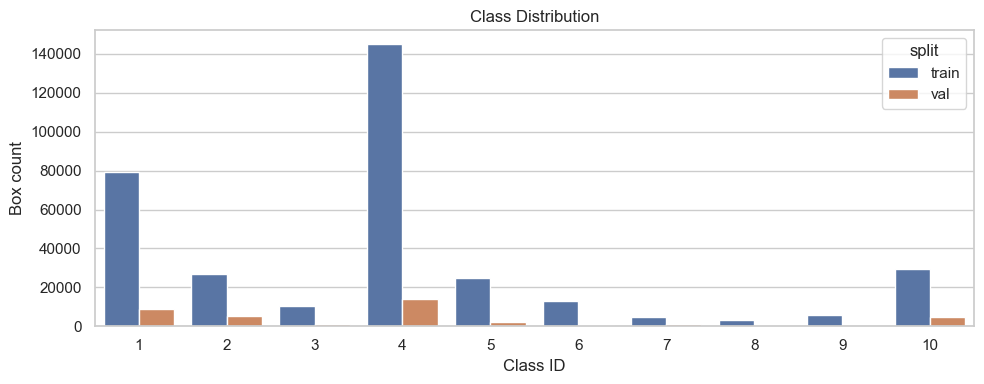

In [6]:
plt.figure(figsize=(10, 4))
sns.barplot(data=class_df, x='class_id', y='count', hue='split')
plt.title('Class Distribution')
plt.xlabel('Class ID')
plt.ylabel('Box count')
plt.tight_layout()
plt.show()


In [7]:
def stats_to_dfs(stats):
    image_sizes = np.array(stats['image_sizes'], dtype=np.float32)
    box_wh = np.array(stats['box_wh'], dtype=np.float32)

    image_df = pd.DataFrame({
        'img_w': image_sizes[:, 0] if image_sizes.size else [],
        'img_h': image_sizes[:, 1] if image_sizes.size else [],
    })

    box_df = pd.DataFrame({
        'box_w': box_wh[:, 0] if box_wh.size else [],
        'box_h': box_wh[:, 1] if box_wh.size else [],
    })
    if stats['box_areas']:
        box_df['box_area'] = stats['box_areas']
    if stats['aspect_ratios']:
        box_df['box_aspect'] = stats['aspect_ratios']

    return image_df, box_df

train_image_df, train_box_df = stats_to_dfs(train_stats)
train_image_df.head()


,img_w,img_h
0,960.0,540.0
1,960.0,540.0
2,960.0,540.0
3,1360.0,765.0
4,1360.0,765.0


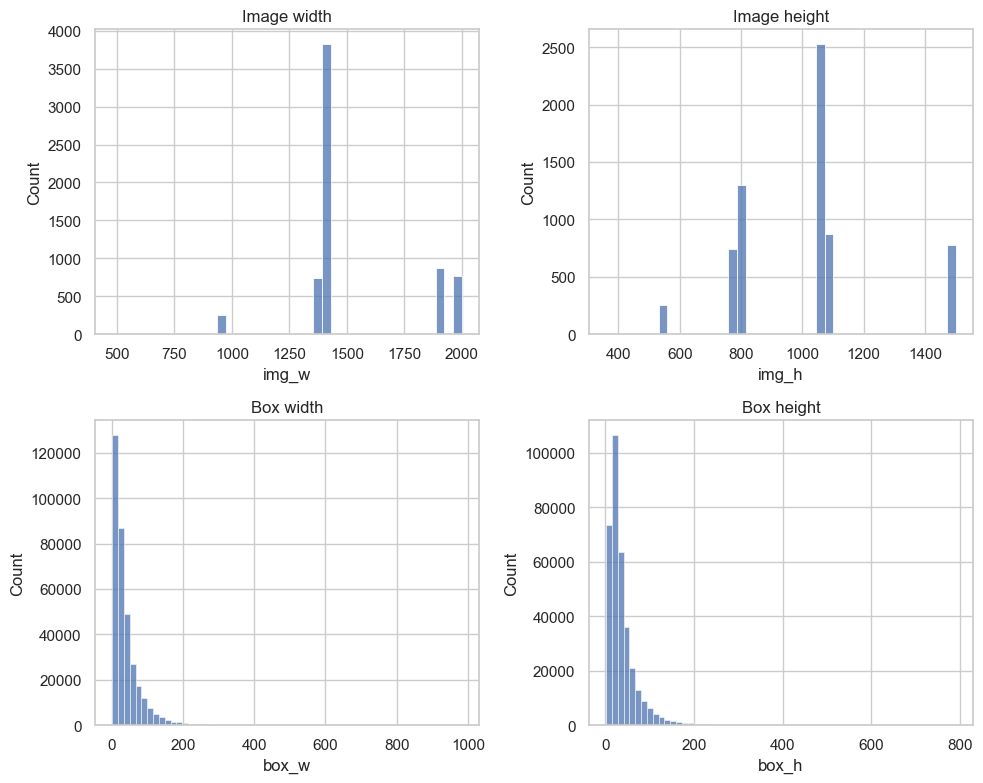

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(train_image_df['img_w'], bins=40, ax=axes[0, 0])
axes[0, 0].set_title('Image width')
sns.histplot(train_image_df['img_h'], bins=40, ax=axes[0, 1])
axes[0, 1].set_title('Image height')
sns.histplot(train_box_df['box_w'], bins=60, ax=axes[1, 0])
axes[1, 0].set_title('Box width')
sns.histplot(train_box_df['box_h'], bins=60, ax=axes[1, 1])
axes[1, 1].set_title('Box height')
plt.tight_layout()
plt.show()


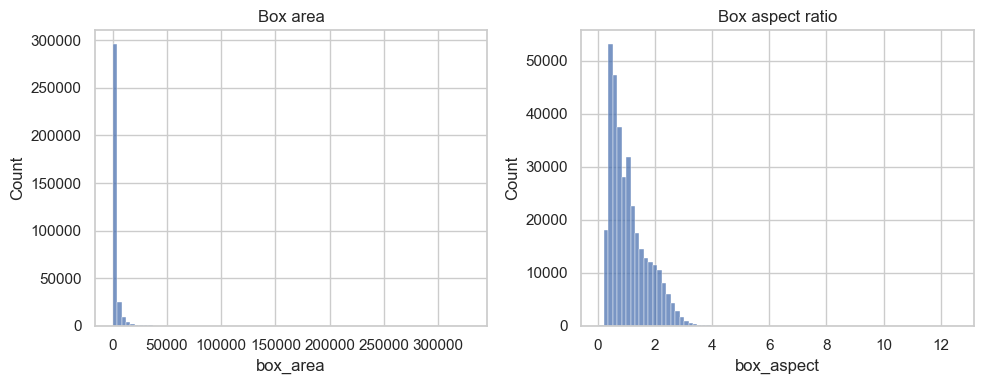

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(train_box_df['box_area'], bins=80, ax=axes[0])
axes[0].set_title('Box area')
sns.histplot(train_box_df['box_aspect'], bins=80, ax=axes[1])
axes[1].set_title('Box aspect ratio')
plt.tight_layout()
plt.show()


In [10]:
def estimate_mean_std(images_dir, sample_limit=500):
    image_paths = [p for p in images_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    if sample_limit and len(image_paths) > sample_limit:
        image_paths = image_paths[:sample_limit]
    pixels_sum = np.zeros(3, dtype=np.float64)
    pixels_sq_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for img_path in image_paths:
        with Image.open(img_path).convert('RGB') as im:
            arr = np.asarray(im, dtype=np.float32) / 255.0
        pixels_sum += arr.reshape(-1, 3).sum(axis=0)
        pixels_sq_sum += (arr.reshape(-1, 3) ** 2).sum(axis=0)
        pixel_count += arr.shape[0] * arr.shape[1]
    mean = pixels_sum / max(pixel_count, 1)
    std = np.sqrt(pixels_sq_sum / max(pixel_count, 1) - mean ** 2)
    return mean, std, len(image_paths)

train_mean, train_std, train_used = estimate_mean_std(train_images_dir, sample_limit=500)
print('Train mean/std (sampled):')
print('  images used:', train_used)
print('  mean:', train_mean)
print('  std :', train_std)


Train mean/std (sampled):
  images used: 500
  mean: [0.40306642 0.41996925 0.3941488 ]
  std : [0.24235016 0.24502798 0.26160778]
